In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import cv2
import numpy as np

## Get first frame of a video

In [10]:
def apply_mask(frame, mask):
  """
    ``apply_mask`` applies a the binary mask `mask` to the given `frame` of a video.

    :param frame: frame of a video in `cv2.COLOR_BGR2GRAY` format
    :param mask: binary mask with same size as `frame`
    :return: returns the frame image with the mask applied
    """ 
  return cv2.bitwise_and(frame, frame, mask=mask)

In [ ]:
filename = "M20251108_192006_MasLaRoca_S.avi"

cap = cv2.VideoCapture(filename)
ret, first_frame = cap.read()
first_frame_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)
cv2.imwrite("M20251108_192006_MasLaRoca_S_first_frame.png", first_frame_gray)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
my_mask = np.zeros((height, width), dtype=np.uint8)
mask_height = height - 30
cv2.rectangle(my_mask, (0, 0), (width, mask_height), 255, thickness=-1)

masked_first_frame = apply_mask(first_frame_gray, my_mask)
cv2.imwrite("M20251108_192006_MasLaRoca_S_first_frame_masked.png", masked_first_frame)

True

## To know how many new samples there are in december 2025

In [3]:
df = pd.read_csv("epochs_model_v1.6_256.csv", sep=";")
df.head(5)

FileNotFoundError: [Errno 2] No such file or directory: 'epochs_model_v1.6_256.csv'

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   epoch     100 non-null    int64  
 1   schedule  100 non-null    float64
 2   loss      100 non-null    float64
 3   accuracy  100 non-null    float64
 4   time      100 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 4.0 KB


In [10]:
df_temp = df[df["year"] == 2025]
df_temp = df_temp[df_temp["month"] == 12]
df_temp = df_temp[df_temp["day"] > 6]
df_temp.shape

(6262, 19)

## To get results from SSL training

In [4]:
epoch36_max_acc = float(df["accuracy"].iloc[:36].max())
epoch36_time = float(df["time"].iloc[:36].sum())
print("Max accuracy at epoch 36:", epoch36_max_acc)
print("Training time until epoch 36:", epoch36_time/3600)


NameError: name 'df' is not defined

In [9]:
max_acc = float(df["accuracy"].max())
time = float(df["time"].sum())
stop_epoch = df["epoch"].iloc[-1]
print("Max accuracy:", max_acc)
print("Training time:", time/3600)
print("Stop-epoch:", stop_epoch)

Max accuracy: 0.695164798393843
Training time: 5.995822073618571
Stop-epoch: 100


# Test set

In [2]:
test_set = pd.read_csv("unknown_labeled.csv", sep=";")

In [3]:
test_set.describe()

,filename,class
count,363,363
unique,363,14
top,M20251215_011509_MasLaRoca_W,car_lights
freq,1,86


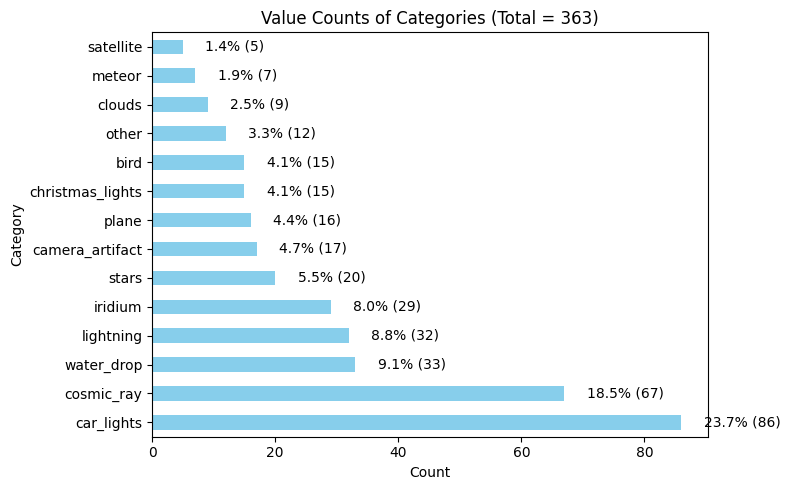

In [16]:
counts = test_set["class"].value_counts()
total = counts.sum()
percentages = counts / total * 100

plt.figure(figsize=(8, 5))

# Horizontal bar plot
counts.plot(kind='barh', color='skyblue')

# Add percentage labels to each bar
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(count + total*0.01, i, f"{pct:.1f}% ({count})", va='center')

plt.xlabel('Count')
plt.ylabel('Category')
plt.title(f'Value Counts of Categories (Total = {total})')

plt.tight_layout()
plt.show()


## Convert Target Variable

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, RobustScaler

# To make the numerical features smooth, reduce skew and heavy tails, make them robust to outliers, and put them on comparable scale
num_preprocess = Pipeline([
    # To make each distribution more Gaussian-like
    #  - reduces skew, stabilizes variance, makes features more symmetric and easier for linear layers to learn from
    ("power", PowerTransformer(method="yeo-johnson")),

    # Scales each feature using median and interquartile range (instead of mean and std)
    #   - resistant to outliers (many in meteor data), so it prevents them from dominating scale  
    ("scale", RobustScaler())
])

X_num = features_df[numerical_variables]
X_num_norm = num_preprocess.fit_transform(X_num)
X_norm = pd.DataFrame(X_num_norm, columns=numerical_variables)
X_norm.head(3)

,time,width,height,mean_brightness,bmin,bmax
0,-0.240716,0.096843,-0.139111,-0.806811,-0.595357,-0.816309
1,-0.240716,0.061371,0.156817,0.014448,0.702609,-0.107325
2,0.100565,0.155826,0.276843,0.071313,0.000000,0.129888


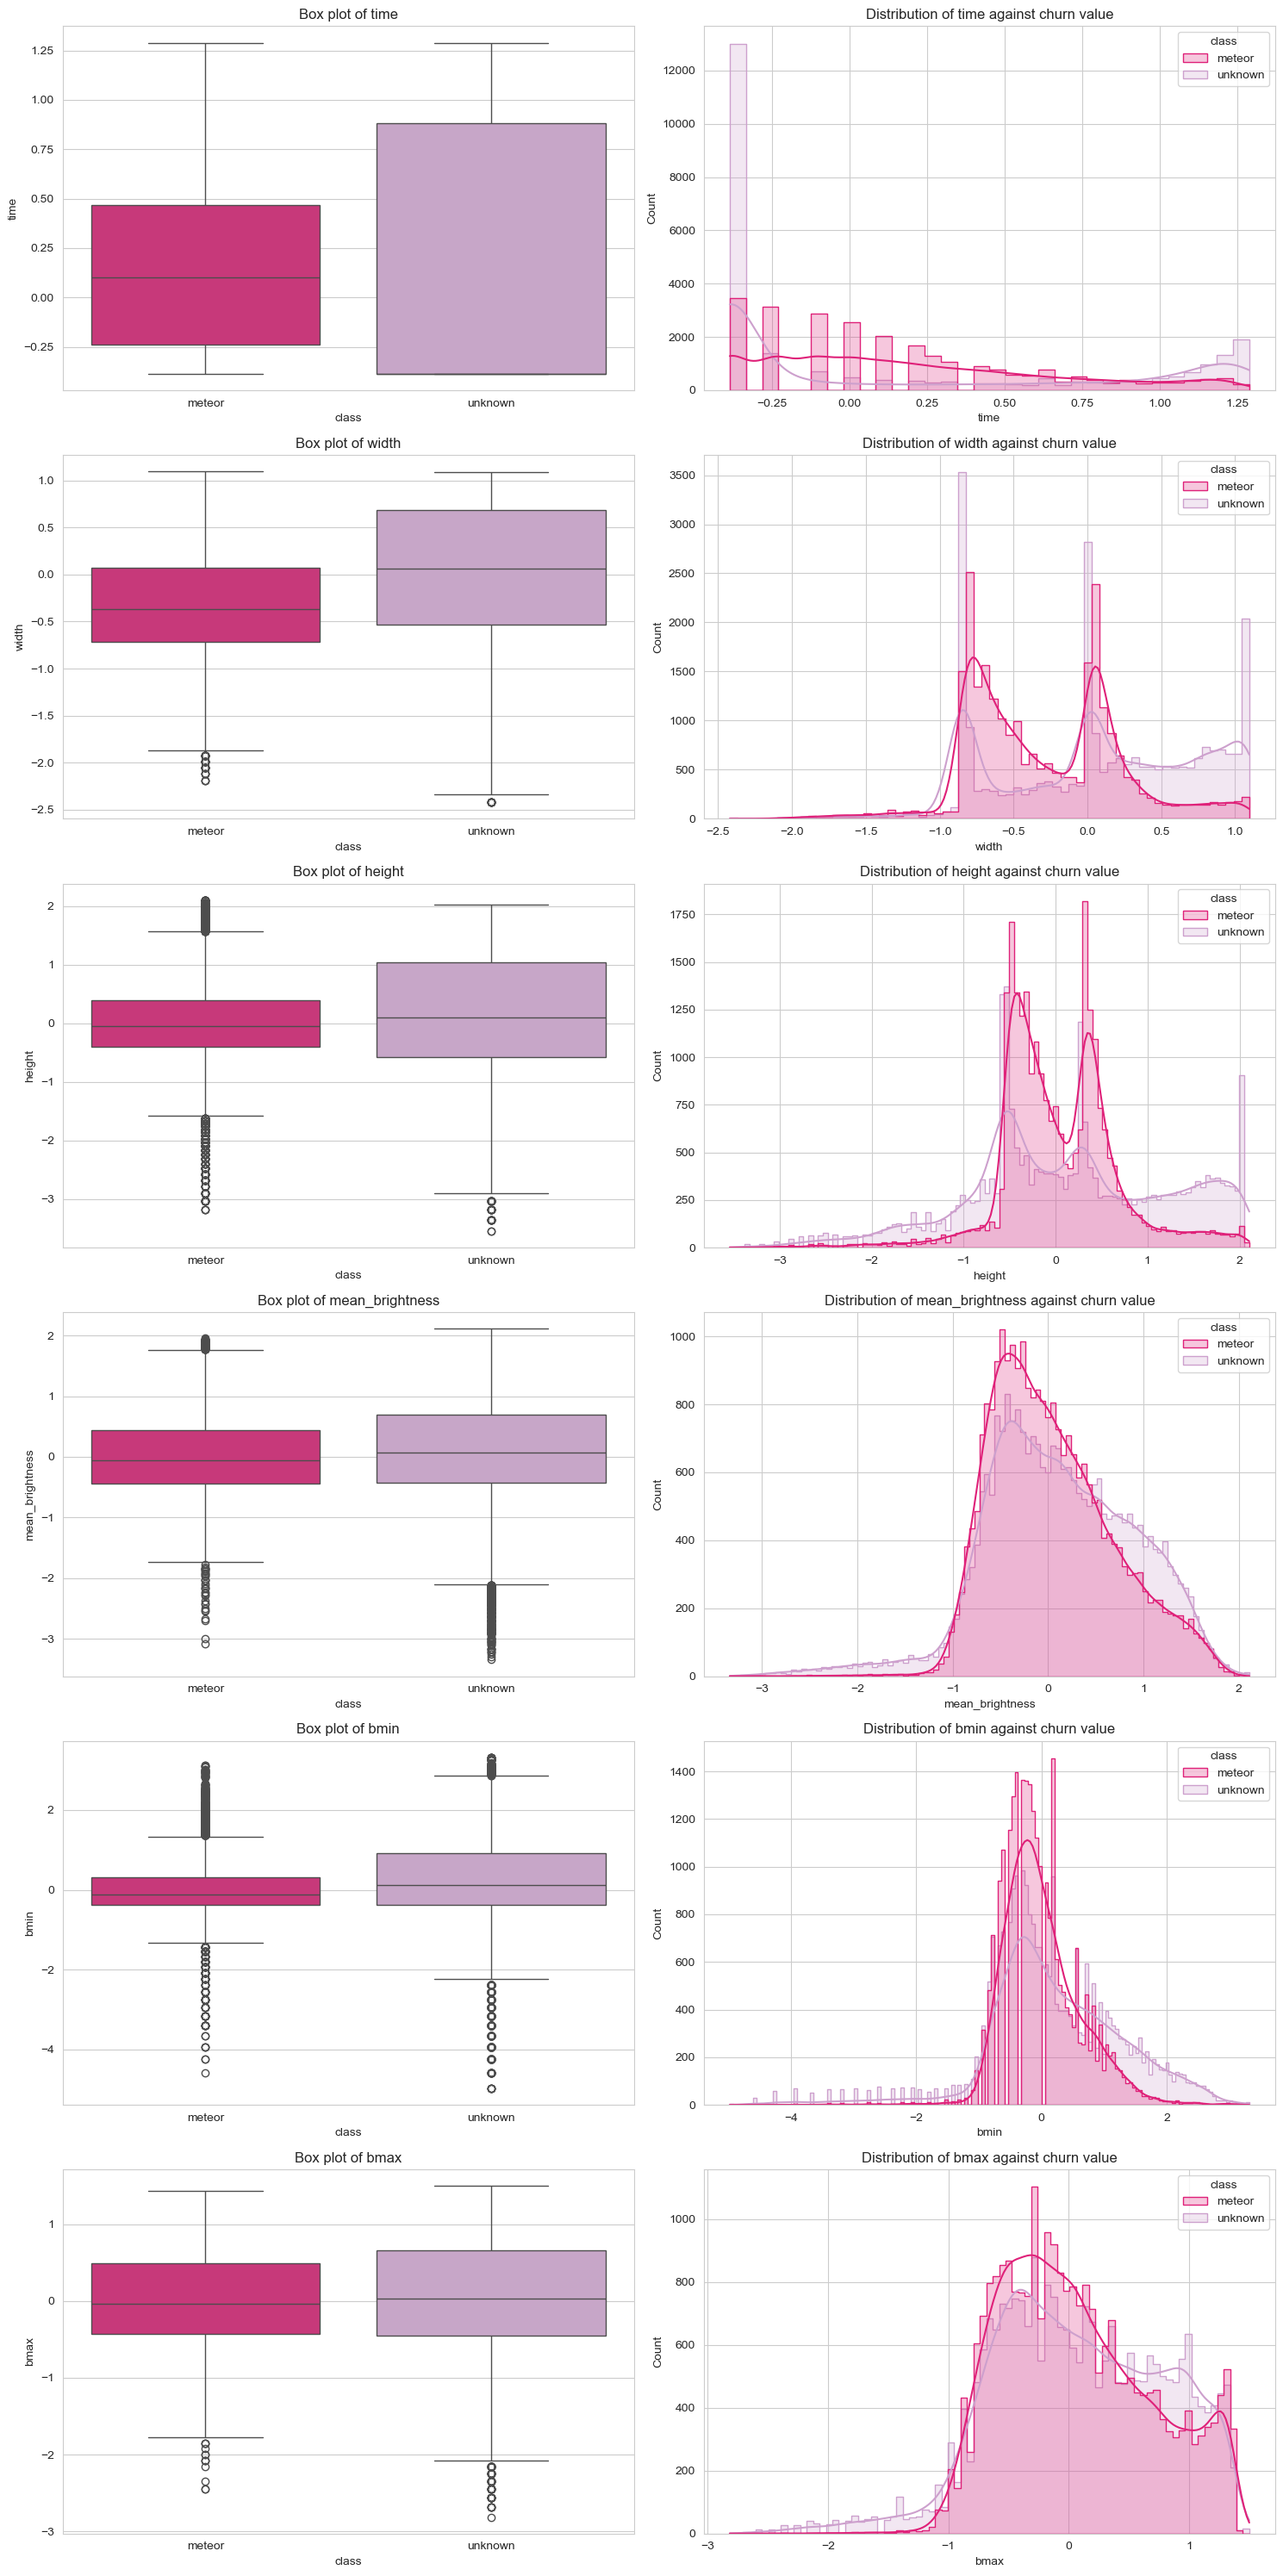

In [ ]:
X_norm["class"] = features_df["class"].values

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Determine the number of rows and columns for the subplot grid
num_vars = len(numerical_variables)
cols = 2  # Two plots for each variable: boxplot and distribution plot
rows = num_vars  # One row for each variable

# Create a figure
fig, axs = plt.subplots(rows, cols, figsize=(15, 5*rows))

# Box plots and distribution plots for numerical variables
for i, column in enumerate(numerical_variables):
    sns.boxplot(x='class', y=column, data=X_norm, hue='class', palette=PALETTE, ax=axs[i, 0])
    axs[i, 0].set_title(f'Box plot of {column}')

    sns.histplot(data=X_norm, x=column, hue='class', palette=PALETTE, kde=True, element='step', ax=axs[i, 1])
    axs[i, 1].set_title(f'Distribution of {column} against churn value')

# Adjust layout
plt.tight_layout()
plt.show()

In [2]:
df = pd.read_csv("dataset_LAST.csv", sep=";")

In [3]:
df_month = df[df['filename'].str.startswith("M202511")]
df_month.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6674 entries, 1920 to 29883
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   filename         6674 non-null   object 
 1   year             6674 non-null   float64
 2   month            6674 non-null   float64
 3   day              6674 non-null   float64
 4   hour             6674 non-null   float64
 5   minute           6674 non-null   float64
 6   lng              6674 non-null   float64
 7   lat              6674 non-null   float64
 8   alt              6674 non-null   float64
 9   camera           6674 non-null   object 
 10  width            6674 non-null   float64
 11  height           6674 non-null   float64
 12  frames           6674 non-null   float64
 13  fps              6674 non-null   float64
 14  time             6674 non-null   float64
 15  mean_brightness  6674 non-null   float64
 16  class            1423 non-null   object 
 17  bmin           